# Firm × technology panel
Unit: firm × IPC subclass × year, 2015–2024.
y = 1 if the firm filed a new patent family in that subclass that year (priority date).
x = number of patent families in that subclass held by the firm's Italian network
    (parent + co-affiliates, self excluded), filed before that year.

In [2]:
import pandas as pd
import numpy as np

data_dir = r"C:\Users\Popov\Documents\Studies\IMT_studies\Projects\Econ_2\Datasets"

patents = pd.read_stata(data_dir + r"\patents.dta")
mnes    = pd.read_stata(r"C:\Users\Popov\Documents\Studies\IMT_studies\Projects\Econ_2\Italian_affiliates_MNEs_2024.dta")

mnes["subs_key"]   = mnes["subs_id"].str.replace("*", "", regex=False).str.strip().str.upper()
mnes["parent_key"] = mnes["parent_id"].str.replace("*", "", regex=False).str.strip().str.upper()

print(patents.shape)
print(patents.columns.tolist())
print(patents.dtypes)

(629225, 10)
['publication_number', 'priority_date', 'grant_date', 'number_of_family_members', 'family_identifier__simple', 'applicant_s__bvd_id_number_s', 'ipc_code__main', 'cpc_code__main', 'backward_citations', 'bvd_key']
publication_number                         str
priority_date                   datetime64[ms]
grant_date                      datetime64[ms]
number_of_family_members               float64
family_identifier__simple              float64
applicant_s__bvd_id_number_s               str
ipc_code__main                             str
cpc_code__main                             str
backward_citations                         str
bvd_key                                    str
dtype: object


The patent table has 629,225 publication-applicant rows across 10 columns. Dates are already
parsed as datetimes, while the Stata export left missing strings as empty rather than NaN —
so text fields are filtered with `!= ""` below.

## Patent families
Collapse publications to families: one row per (firm, family), with the earliest priority
date and the family's modal IPC subclass. This is the unit of "a patent was created".

In [3]:
subs_set = set(mnes["subs_key"])

# affiliate-owned publications with the fields we need
# (clean_cols wrote missing strings as "", so test against "" not NaN)
aff = patents[
    patents["bvd_key"].isin(subs_set)
    & (patents["ipc_code__main"] != "")
    & patents["priority_date"].notna()
    & patents["family_identifier__simple"].notna()
].copy()

aff["fam_id"]   = aff["family_identifier__simple"].astype("Int64")
aff["subclass"] = aff["ipc_code__main"].str[:4]          # e.g. C07D207/34 -> C07D

print("affiliate publications:", len(aff))
print("dropped (no IPC / date / family):",
      patents["bvd_key"].isin(subs_set).sum() - len(aff))
print("distinct subclasses:", aff["subclass"].nunique())

affiliate publications: 256729
dropped (no IPC / date / family): 142527
distinct subclasses: 655


Of 399,256 affiliate-owned publications, 256,729 (64%) carry an IPC code, a priority date and
a family identifier; the rest are dropped as unusable. These span 655 IPC subclasses, the
technology dimension of the panel.

In [4]:
# modal subclass per (firm, family): count, sort, keep the top row
cnt = (aff.groupby(["bvd_key", "fam_id", "subclass"], observed=True)
         .size().reset_index(name="n")
         .sort_values(["bvd_key", "fam_id", "n", "subclass"],
                      ascending=[True, True, False, True]))
fam_class = cnt.drop_duplicates(["bvd_key", "fam_id"])[["bvd_key", "fam_id", "subclass"]]

# earliest priority date per (firm, family)
fam_date = (aff.groupby(["bvd_key", "fam_id"], observed=True)["priority_date"]
              .min().reset_index().rename(columns={"priority_date": "prio_date"}))

fam = fam_class.merge(fam_date, on=["bvd_key", "fam_id"])
fam["year"] = fam["prio_date"].dt.year

print("firm-family rows:", len(fam))
print("distinct families:", fam["fam_id"].nunique())
print("priority years:", fam["year"].min(), "-", fam["year"].max())
print(fam.head())

firm-family rows: 67900
distinct families: 67093
priority years: 1900 - 2025
         bvd_key    fam_id subclass  prio_date  year
0  IT00002890408  11104658     E02D 1990-01-11  1990
1  IT00002890408  11106529     E01C 1987-03-20  1987
2  IT00002890408  11107526     E21D 1989-04-28  1989
3  IT00002890408  11301651     E21D 1990-05-11  1990
4  IT00002890408  11302174     E21D 1990-06-07  1990


Collapsing to families gives 67,900 firm-family rows covering 67,093 distinct families — the
small gap reflects families co-owned by two affiliates, each counted as a separate creation
event. Priority years span 1900–2025; the panel is restricted to 2015–2024, with earlier
families retained to build the network stock.

In [5]:
print(fam["year"].value_counts().sort_index().head(10))

year
1900     1
1906     1
1908     1
1910     1
1912     1
1914     2
1917     1
1918     6
1919    13
1920     1
Name: count, dtype: int64


The pre-war filings are genuine rather than coerced nulls — they appear as isolated singletons
across distinct years, not as a lump on 1900, and several sample firms are long-established
Italian manufacturers. They fall outside the 2015–2024 estimation window and enter only
through the cumulative network stock.

## Network membership
Each firm's local network = the other Italian affiliates sharing its ultimate owner.
Self is excluded, so a firm never counts as its own network.

In [6]:
sub2par = mnes.set_index("subs_key")["parent_key"].to_dict()

# firms that actually appear in the family table, by group
fam["parent_key"] = fam["bvd_key"].map(sub2par)

# families owned by each group-year-subclass (the pool the network stock draws on)
grp_fam = (fam.dropna(subset=["parent_key"])
             .groupby(["parent_key", "subclass", "year"], observed=True)
             .agg(n_fam=("fam_id", "nunique"))
             .reset_index())

print("group-subclass-year cells:", len(grp_fam))
print("groups with any family:", grp_fam["parent_key"].nunique())

group-subclass-year cells: 28658
groups with any family: 2097


In [7]:
# eligible firms: patenting, and in a group with >=1 other patenting affiliate
pat_per_grp = fam.groupby("parent_key")["bvd_key"].nunique()
eligible = sorted({b for b in fam["bvd_key"].unique()
                   if pat_per_grp.get(sub2par.get(b), 0) >= 2})

print("patenting affiliates:", fam["bvd_key"].nunique())
print("...with >=1 patenting co-affiliate:", len(eligible))

patenting affiliates: 2507
...with >=1 patenting co-affiliate: 674


Aggregating families to the group level gives 28,658 group-subclass-year cells across 2,097
groups. Of 2,507 patenting affiliates, 674 belong to a group containing at least one other
patenting affiliate — these are the firms with potential network exposure and form the
estimation sample.

Moving from citations to technology classes widens the identifying sample considerably: 674
firms carry potential network exposure, against 181 with any in-network citation under the
previous approach. The gain comes from dropping the requirement that a citation link the firm
to its network — co-patenting in the same subclass is enough — and each firm now contributes
a full subclass-year grid rather than a single share.

Example. Affiliate A and its co-affiliate B both file patents in subclass C07D. Under the
citation approach this counts only if A's patent explicitly cites B's; otherwise A contributes
nothing. Under the technology approach it is enough that both patent in C07D — A gets a
creation event and a network stock in that subclass. The proxy is weaker evidence of an actual
knowledge flow, but it applies to far more firms, which is why the citation results are kept
as descriptives.

## Panel grid
One row per firm × IPC subclass × year, 2015–2024. The subclass grid is restricted to
subclasses the firm or its network ever touches — elsewhere both y and x are zero by
construction and contribute nothing under fixed effects.

In [8]:
YEARS = range(2015, 2025)

# subclasses each group is ever active in (firm's own + its co-affiliates')
grp_sub = (fam.dropna(subset=["parent_key"])[["parent_key", "subclass"]]
             .drop_duplicates())

# eligible firms with their group
firm_grp = pd.DataFrame({"bvd_key": eligible})
firm_grp["parent_key"] = firm_grp["bvd_key"].map(sub2par)

# grid = firm x (subclasses its group ever touches) x years
grid = (firm_grp.merge(grp_sub, on="parent_key")
                .merge(pd.DataFrame({"year": list(YEARS)}), how="cross"))

print("panel rows:", f"{len(grid):,}")
print("firms:", grid["bvd_key"].nunique(),
      "| subclasses:", grid["subclass"].nunique())

panel rows: 94,010
firms: 674 | subclasses: 527


In [9]:
# y: did the firm file a new family in this subclass this year?
y = (fam[fam["year"].between(2015, 2024)]
       .groupby(["bvd_key", "subclass", "year"], observed=True)
       .size().reset_index(name="n_new"))

panel = grid.merge(y, on=["bvd_key", "subclass", "year"], how="left")
panel["n_new"]   = panel["n_new"].fillna(0).astype("int16")
panel["patented"] = (panel["n_new"] > 0).astype("int8")

print("panel rows:", f"{len(panel):,}")
print("cells with a new family:", f'{panel["patented"].sum():,}',
      f'({panel["patented"].mean():.2%})')

panel rows: 94,010
cells with a new family: 3,406 (3.62%)


The grid holds 94,010 firm-subclass-year cells: 674 firms across 527 subclasses over ten
years. Restricting to subclasses each group is ever active in keeps the panel small — the
unrestricted grid would be 4.4M rows, almost all of them cells no group member has ever
patented in.

## Network stock
x = number of distinct patent families in this subclass filed before year t by the firm's
Italian co-affiliates. Families the firm co-owns are excluded, so the regressor never
mechanically contains the outcome.

In [10]:
# families by (group, subclass, year), listing the owners so we can exclude the focal firm
fam_g = fam.dropna(subset=["parent_key"]).copy()

# every (focal firm, co-affiliate family) pair within a group
pairs = (fam_g[["parent_key", "subclass", "year", "fam_id", "bvd_key"]]
           .merge(firm_grp, on="parent_key", suffixes=("_owner", "_focal")))

# drop families the focal firm itself owns (covers co-applied families too)
own_fams = set(zip(fam["bvd_key"], fam["fam_id"]))
keep = [ (f, fi) not in own_fams
         for f, fi in zip(pairs["bvd_key_focal"], pairs["fam_id"]) ]
pairs = pairs[keep]

print("firm x co-affiliate family pairs:", f"{len(pairs):,}")

firm x co-affiliate family pairs: 52,864


In [11]:
YEARS = list(range(2015, 2025))

# distinct co-affiliate families per (focal firm, subclass, filing year)
net = (pairs.groupby(["bvd_key_focal", "subclass", "year"])["fam_id"]
         .nunique().reset_index(name="n")
         .rename(columns={"bvd_key_focal": "bvd_key"}))

# pool everything filed before the window into one pre-window bucket
net["yr"] = net["year"].clip(lower=2014)
net = net.groupby(["bvd_key", "subclass", "yr"])["n"].sum().reset_index()

# complete 2014-2024 index per firm-subclass, then cumulate
full = (net[["bvd_key", "subclass"]].drop_duplicates()
          .merge(pd.DataFrame({"yr": [2014] + YEARS}), how="cross")
          .merge(net, on=["bvd_key", "subclass", "yr"], how="left"))
full["n"] = full["n"].fillna(0)
full = full.sort_values(["bvd_key", "subclass", "yr"])
full["cum"] = full.groupby(["bvd_key", "subclass"])["n"].cumsum()

# stock in year t = everything filed strictly before t = cumulative at t-1
full["year"] = full["yr"] + 1
stock = (full.loc[full["year"].between(2015, 2024),
                  ["bvd_key", "subclass", "year", "cum"]]
             .rename(columns={"cum": "net_stock"}))

panel = panel.drop(columns=["net_stock", "net_any", "log_net"], errors="ignore")
panel = panel.merge(stock, on=["bvd_key", "subclass", "year"], how="left")
panel["net_stock"] = panel["net_stock"].fillna(0).astype("int32")
panel["net_any"]   = (panel["net_stock"] > 0).astype("int8")
panel["log_net"]   = np.log1p(panel["net_stock"])

print("cells with stock > 0:", f'{panel["net_any"].sum():,}',
      f'({panel["net_any"].mean():.1%})')
print("firms with stock > 0 somewhere:",
      panel.loc[panel["net_stock"] > 0, "bvd_key"].nunique(),
      "of", panel["bvd_key"].nunique())

cells with stock > 0: 56,612 (60.2%)
firms with stock > 0 somewhere: 671 of 674


## Correlation matrix
The stock is heavily skewed, so it enters in three forms: level, log(1+x), and a binary
indicator. The `foreign` flag is carried through for the heterogeneity split.

In [12]:
panel["log_net"] = np.log1p(panel["net_stock"])

# parent nationality, for the foreign vs Italian split
panel["parent_is_foreign"] = panel["bvd_key"].map(
    mnes.set_index("subs_key")["foreign"].to_dict())

# fixed-effect keys
panel["firm_year"] = panel["bvd_key"] + "_" + panel["year"].astype(str)
panel["sub_year"]  = panel["subclass"] + "_" + panel["year"].astype(str)

print(panel.groupby("parent_is_foreign")["bvd_key"].nunique())

parent_is_foreign
0.0    532
1.0    142
Name: bvd_key, dtype: int64


In [13]:
from scipy.stats import pearsonr

VARS   = ["patented", "net_stock", "log_net", "net_any"]
LABELS = {"patented": "Patented (0/1)", "net_stock": "Network stock",
          "log_net": "log(1 + stock)", "net_any": "Network active (0/1)"}

def stars(p):
    return "***" if p < .01 else "**" if p < .05 else "*" if p < .1 else ""

# lower triangle only — the upper half is redundant
rows = [LABELS[v] for v in VARS]
M = pd.DataFrame("", index=rows, columns=rows)
for i, a in enumerate(VARS):
    for j, b in enumerate(VARS):
        if i == j:
            M.iloc[i, j] = "1"
        elif i > j:
            r, p = pearsonr(panel[a], panel[b])
            M.iloc[i, j] = f"{r:.3f}{stars(p)}"

(M.style
  .set_caption(f"Pairwise correlations, firm × subclass × year cells (N = {len(panel):,})"
               "<br><span style='font-size:85%;color:#666'>"
               "*** p&lt;0.01, ** p&lt;0.05, * p&lt;0.1</span>")
  .set_properties(**{"text-align": "right", "font-family": "serif"})
  .set_table_styles([
      {"selector": "caption", "props": "caption-side: top; text-align: left; "
                                       "font-weight: bold; padding-bottom: 8px;"},
      {"selector": "th", "props": "text-align: right; font-family: serif;"},
      {"selector": "th.row_heading", "props": "text-align: left;"},
  ]))

,Patented (0/1),Network stock,log(1 + stock),Network active (0/1)
Patented (0/1),1,,,
Network stock,0.013***,1,,
log(1 + stock),-0.060***,0.547***,1,
Network active (0/1),-0.125***,0.159***,0.686***,1


Negative ans significant coefs. Strange. Let's analyze them


In [14]:
# LaTeX version of the same table (printed, not saved)
body = ""
for i, a in enumerate(VARS):
    cells = []
    for j, b in enumerate(VARS):
        if i == j:
            cells.append("1")
        elif i > j:
            r, p = pearsonr(panel[a], panel[b])
            s = stars(p)
            cells.append(f"{r:.3f}$^{{{s}}}$" if s else f"{r:.3f}")
        else:
            cells.append("")                       # upper triangle left blank
    body += f"({i+1}) {LABELS[a]} & " + " & ".join(cells) + r" \\" + "\n"

header = " & ".join(f"({i+1})" for i in range(len(VARS)))
lines = [
    r"\begin{table}[htbp]",
    r"\centering",
    r"\caption{Pairwise correlations, firm $\times$ subclass $\times$ year cells}",
    r"\label{tab:corr}",
    r"\begin{tabular}{l" + "c" * len(VARS) + "}",
    r"\toprule",
    " & " + header + r" \\",
    r"\midrule",
    body + r"\bottomrule",
    r"\end{tabular}",
    r"\begin{minipage}{\linewidth}\vspace{4pt}\footnotesize",
    rf"\textit{{Notes:}} N = {len(panel):,} firm-subclass-year cells, 2015--2024.",
    r"$^{***}$ $p<0.01$, $^{**}$ $p<0.05$, $^{*}$ $p<0.1$.",
    r"\end{minipage}",
    r"\end{table}",
]
print("\n".join(lines))

\begin{table}[htbp]
\centering
\caption{Pairwise correlations, firm $\times$ subclass $\times$ year cells}
\label{tab:corr}
\begin{tabular}{lcccc}
\toprule
 & (1) & (2) & (3) & (4) \\
\midrule
(1) Patented (0/1) & 1 &  &  &  \\
(2) Network stock & 0.013$^{***}$ & 1 &  &  \\
(3) log(1 + stock) & -0.060$^{***}$ & 0.547$^{***}$ & 1 &  \\
(4) Network active (0/1) & -0.125$^{***}$ & 0.159$^{***}$ & 0.686$^{***}$ & 1 \\
\bottomrule
\end{tabular}
\begin{minipage}{\linewidth}\vspace{4pt}\footnotesize
\textit{Notes:} N = 94,010 firm-subclass-year cells, 2015--2024.
$^{***}$ $p<0.01$, $^{**}$ $p<0.05$, $^{*}$ $p<0.1$.
\end{minipage}
\end{table}


In [15]:
# is this a subclass the firm itself ever patents in?
own_sub = set(zip(fam["bvd_key"], fam["subclass"]))
panel["own_subclass"] = [ (b, s) in own_sub for b, s in zip(panel["bvd_key"], panel["subclass"]) ]

ROW = {False: "Firm never patents in this subclass", True: "Firm's own subclass"}
COL = {0: "No network stock", 1: "Network stock > 0"}

g = (panel.groupby(["own_subclass", "net_any"])
       .agg(cells=("patented", "size"), rate=("patented", "mean"))
       .reset_index())
g["row"] = g["own_subclass"].map(ROW)
g["col"] = g["net_any"].map(COL)
g["txt"] = [f"{r:.1%}<br><span style='color:#777;font-size:85%'>{c:,} cells</span>"
            for r, c in zip(g["rate"], g["cells"])]

tab = (g.pivot(index="row", columns="col", values="txt")
         .reindex(index=[ROW[True], ROW[False]],
                  columns=[COL[0], COL[1]]))
tab.index.name = None; tab.columns.name = None

(tab.style
   .set_caption("Share of cells with a new patent family, by network exposure"
                "<br><span style='font-size:85%;color:#666'>"
                "Firm × subclass × year cells, 2015–2024</span>")
   .set_properties(**{"text-align": "center", "font-family": "serif",
                      "padding": "6px 14px"})
   .set_table_styles([
       {"selector": "caption", "props": "caption-side: top; text-align: left; "
                                        "font-weight: bold; padding-bottom: 8px;"},
       {"selector": "th", "props": "text-align: center; font-family: serif;"},
       {"selector": "th.row_heading", "props": "text-align: left;"},
   ]))

,No network stock,Network stock > 0
Firm's own subclass,"8.6%28,312 cells","13.0%7,508 cells"
Firm never patents in this subclass,"0.0%9,086 cells","0.0%49,104 cells"


In [16]:
# LaTeX version (printed, not saved)
ROW_TEX = {False: "Firm never patents in this subclass", True: "Firm's own subclass"}
COL_TEX = {0: "No network stock", 1: r"Network stock $>$ 0"}

lines = [
    r"\begin{table}[htbp]",
    r"\centering",
    r"\caption{Share of cells with a new patent family, by network exposure}",
    r"\label{tab:exposure}",
    r"\begin{tabular}{lcc}",
    r"\toprule",
    " & " + COL_TEX[0] + " & " + COL_TEX[1] + r" \\",
    r"\midrule",
]
for own in (True, False):                       # own-subclass row first
    sub = g[g["own_subclass"] == own].set_index("net_any")
    rates = " & ".join(f"{sub.loc[k, 'rate']:.1%}".replace("%", r"\%") for k in (0, 1))
    ns    = " & ".join(f"[{int(sub.loc[k, 'cells']):,}]" for k in (0, 1))
    lines += [ROW_TEX[own] + " & " + rates + r" \\",
              r" & " + ns + r" \\",
              r"\addlinespace"]
lines += [
    r"\bottomrule",
    r"\end{tabular}",
    r"\begin{minipage}{\linewidth}\vspace{4pt}\footnotesize",
    r"\textit{Notes:} Firm $\times$ IPC subclass $\times$ year cells, 2015--2024. "
    r"Number of cells in brackets. Cells in subclasses the firm never patents in are "
    r"structural zeros and drop out under firm $\times$ subclass fixed effects.",
    r"\end{minipage}",
    r"\end{table}",
]
print("\n".join(lines))

\begin{table}[htbp]
\centering
\caption{Share of cells with a new patent family, by network exposure}
\label{tab:exposure}
\begin{tabular}{lcc}
\toprule
 & No network stock & Network stock $>$ 0 \\
\midrule
Firm's own subclass & 8.6\% & 13.0\% \\
 & [28,312] & [7,508] \\
\addlinespace
Firm never patents in this subclass & 0.0\% & 0.0\% \\
 & [9,086] & [49,104] \\
\addlinespace
\bottomrule
\end{tabular}
\begin{minipage}{\linewidth}\vspace{4pt}\footnotesize
\textit{Notes:} Firm $\times$ IPC subclass $\times$ year cells, 2015--2024. Number of cells in brackets. Cells in subclasses the firm never patents in are structural zeros and drop out under firm $\times$ subclass fixed effects.
\end{minipage}
\end{table}


In [17]:
# the contrast that matters, on the firm's own subclasses
own = panel[panel["own_subclass"]]
r0, r1 = own.loc[own["net_any"] == 0, "patented"].mean(), own.loc[own["net_any"] == 1, "patented"].mean()
print(f"own subclasses: {r1:.1%} with network stock vs {r0:.1%} without "
      f"({r1/r0 - 1:+.0%})")
print(f"structural zeros: {(~panel['own_subclass']).sum():,} of {len(panel):,} cells "
      f"({(~panel['own_subclass']).mean():.0%}) — firm never patents in that subclass")

own subclasses: 13.0% with network stock vs 8.6% without (+52%)
structural zeros: 58,190 of 94,010 cells (62%) — firm never patents in that subclass


## Reading the two tables

The cross-tab is the result; the correlation matrix is not.

The panel gives every firm a row for its co-affiliates' technologies as well as its own. A firm
doing chemistry therefore gets rows for a sibling's machinery subclasses: exposed, but it will
never patent there. There are 58,190 such cells, 62% of the panel, zero by construction and
mostly on the exposed side. Averaging over them makes exposure look like it suppresses
patenting, which is backwards — hence the negative pooled correlation.

Restricting to subclasses the firm actually works in removes the artifact. There, a new patent
family appears in 13.0% of years when the network already has a stock in that subclass, against
8.6% when it does not. That is the association the design is about, and it is positive.

## Checks 
Before proper estimation, let's check whether we have enough variance.

In [18]:
pair = panel.groupby(["bvd_key", "subclass"])["patented"].agg(["mean", "size"])
varying = pair[(pair["mean"] > 0) & (pair["mean"] < 1)]
print(f"firm-subclass pairs: {len(pair):,}")
print(f"...with variation in y: {len(varying):,} ({len(varying)/len(pair):.1%})")
print(f"cells in those pairs: {varying['size'].sum():,}")

firm-subclass pairs: 9,401
...with variation in y: 1,676 (17.8%)
cells in those pairs: 16,760


In [19]:
print("firms represented in the identifying pairs:",
      varying.reset_index()["bvd_key"].nunique())

firms represented in the identifying pairs: 430


Seems like we do!|

## Sample summary

| Step | Firms |
|---|---|
| Italian affiliates | 37,263 |
| ...patenting | 2,507 |
| ...in the estimation sample (patenting, with a patenting co-affiliate) | 674 |
| ...with network exposure in at least one cell | 671 |
| ...identifying, under firm × subclass fixed effects | 430 |

Identification rests on 1,676 firm-subclass pairs and 16,760 cells — the pairs where the firm
patents in some years of the window but not others. The remaining pairs are constant in the
outcome and drop out.

Descriptively, within subclasses a firm works in, a new patent family appears in 13.0% of years
when its network already holds a stock there, against 8.6% when it does not.

## Cascading plot

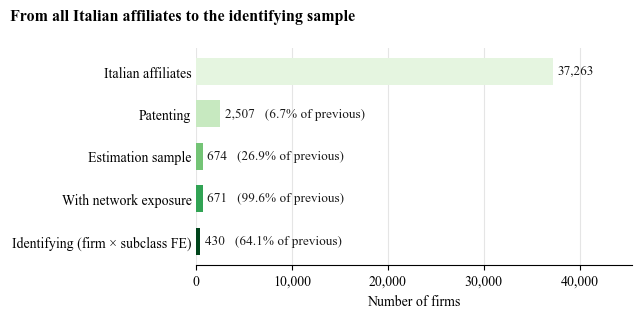

In [20]:
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

fig_dir = r"C:\Users\Popov\Documents\Studies\IMT_studies\Projects\Econ_2\Figures"
os.makedirs(fig_dir, exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "pdf.fonttype": 42,      # embed fonts as TrueType
    "ps.fonttype": 42,
})

# firms that identify: firm-subclass pairs with variation in the outcome
_pair = panel.groupby(["bvd_key", "subclass"])["patented"].mean()
_ident = (_pair[(_pair > 0) & (_pair < 1)].reset_index()["bvd_key"].nunique())

steps = [
    ("Italian affiliates",               mnes["subs_key"].nunique()),
    ("Patenting",                        fam["bvd_key"].nunique()),
    ("Estimation sample",                panel["bvd_key"].nunique()),
    ("With network exposure",            panel.loc[panel["net_stock"] > 0, "bvd_key"].nunique()),
    ("Identifying (firm × subclass FE)", _ident),
]
labels = [s[0] for s in steps]
values = [s[1] for s in steps]
y = list(range(len(steps)))

# sequential green ramp, light -> dark as the sample narrows
colors = ["#e5f5e0", "#c7e9c0", "#74c476", "#31a354", "#00441b"]

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.barh(y, values, color=colors, height=0.64, edgecolor="none", zorder=3)
ax.invert_yaxis()
ax.set_yticks(y)
ax.set_yticklabels(labels)

xmax = values[0]
for i, v in enumerate(values):
    txt = f"{v:,}" + (f"   ({v / values[i-1]:.1%} of previous)" if i > 0 else "")
    ax.text(v + xmax * 0.012, i, txt, va="center", ha="left",
            fontsize=9.5, color="#1a1a1a", zorder=4)

fig.suptitle("From all Italian affiliates to the identifying sample",
             x=0.02, ha="left", fontsize=11.5, fontweight="bold")
ax.set_xlim(0, xmax * 1.22)
ax.set_xlabel("Number of firms")
ax.xaxis.set_major_locator(MultipleLocator(10000))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(axis="x", color="#e5e5e5", linewidth=0.8, zorder=0)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)

fig.tight_layout()
fig.savefig(os.path.join(fig_dir, "estimation_funnel.pdf"), bbox_inches="tight")
plt.show()